In [1]:
import pandas as pd

# 1. Cargar los archivos
# Asegúrate de que los nombres coincidan con tus archivos locales
df_irene = pd.read_excel('datos_ieq_irene_2023_merge_final.xlsx')
df_avellanos = pd.read_excel('datos_ieq_avellanos_2023_merge_final.xlsx')

# 2. Crear la columna identificadora en cada uno
df_irene['escuela'] = 'Irene Frei'
df_avellanos['escuela'] = 'Los Avellanos'

# 3. Unir las tablas (una debajo de la otra)
# Usamos concat porque tienen las mismas columnas
df_final = pd.concat([df_irene, df_avellanos], ignore_index=True)

# 4. Verificar el resultado
print(df_final['escuela'].value_counts())
# Esto te mostrará cuántos datos hay de cada una en el mismo archivo

escuela
Irene Frei       32456
Los Avellanos     6010
Name: count, dtype: int64


In [2]:
# Definimos una función de estilo para aplicar el color rosa pastel (#FFD1DC)
def style_pastel_pink(df):
    return df.head().style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#FFD1DC'), ('color', '#333'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('background-color', '#FFF0F5')]} # Un rosa aún más claro para el cuerpo
    ]).set_properties(**{'border': '1.5px solid white'})

In [3]:
# Verificación visual 
print("📊 Dataset Df: Calidad de Aire en Salas de Clases Colegio Irene & Colegio Avellanos")
display(style_pastel_pink(df_final))

📊 Dataset Df: Calidad de Aire en Salas de Clases Colegio Irene & Colegio Avellanos


,date,temp_int1,hum_int1,CO2_int1,PM 2.5_int1,PM 10_int1,temp_int2,hum_int2,CO2_int2,PM 2.5_int2,PM 10_int2,temp_ext,hum_ext,CO2_ext,PM 2.5_ext,PM 10_ext,escuela
0,2023-04-20 14:30:00,20.780000,66.210000,1011.350000,12.960000,15.310000,20.850000,66.830000,796.180000,10.270000,20.190000,17.494348,75.076320,406.455829,13.060778,19.088471,Irene Frei
1,2023-04-21 11:00:00,20.720000,70.420000,1346.320000,10.440000,15.060000,20.230000,72.820000,1438.160000,6.140000,10.670000,17.758792,75.302252,420.272067,9.727599,15.397579,Irene Frei
2,2023-04-24 23:20:00,109.490000,68.000000,412.870000,61.410000,67.090000,17.500000,67.700000,949.620000,60.250000,77.790000,59.475170,74.049808,410.898998,66.162385,71.061827,Irene Frei
3,2023-04-28 05:00:00,20.600000,0.810000,396.090000,8.780000,9.570000,17.900000,76.710000,395.050000,6.860000,9.000000,21.077079,47.438806,455.281836,11.553041,10.143717,Irene Frei
4,2023-04-28 08:20:00,22.910000,31.230000,672.520000,5.040000,28.480000,18.320000,76.160000,644.820000,4.680000,9.860000,21.706049,58.045136,444.294087,5.624613,20.399886,Irene Frei


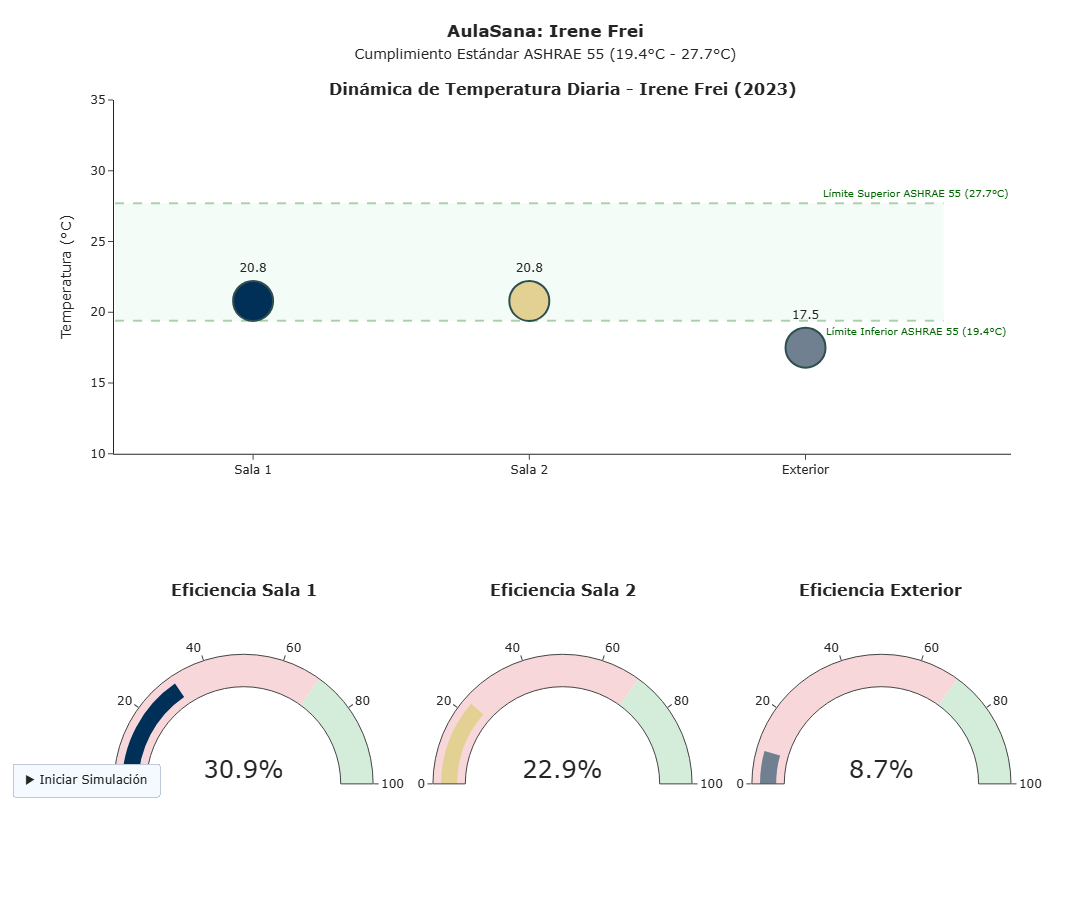

In [13]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. CONFIGURACIÓN INICIAL Y FILTRADO DOBLE ---
nombre_colegio = 'Irene Frei' 

# Aplicamos filtro por Colegio Y por Año (2023)
df_filtrado = df_final[
    (df_final['escuela'] == nombre_colegio) & 
    (df_final['date'].dt.year == 2023)
].copy()

def get_compliance(series):
    if len(series) == 0: return 0
    within_range = series.between(19.4, 27.7).sum()
    return round((within_range / len(series)) * 100, 1)

# --- 2. PROCESAMIENTO Y VALIDACIÓN ---
if df_filtrado.empty:
    print(f"❌ Error: No hay datos para {nombre_colegio} en el año 2023")
    print("Colegios disponibles:", df_final['escuela'].unique())
    print("Años disponibles:", df_final['date'].dt.year.unique())
else:
    # Agrupamos por día (Aseguramos que 'Day' exista en df_filtrado)
    df_filtrado['Day'] = df_filtrado['date'].dt.strftime('%Y-%m-%d')
    
    cols_map = {'temp_int1': 'Sala 1', 'temp_int2': 'Sala 2', 'temp_ext': 'Exterior'}
    df_daily = df_filtrado.groupby('Day')[list(cols_map.keys())].mean().reset_index()
    df_daily = df_daily.rename(columns=cols_map).round(1)

    if df_daily.empty:
        print("❌ Error: No se pudo generar el resumen diario.")
    else:
        # --- 3. CREACIÓN DEL GRÁFICO (El resto del código se mantiene igual) ---
        fig = make_subplots(
            rows=2, cols=3,
            row_heights=[0.6, 0.4], 
            vertical_spacing=0.2,   
            specs=[[{"colspan": 3}, None, None],
                   [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
            subplot_titles=(
                f"<b>Dinámica de Temperatura Diaria - {nombre_colegio} (2023)</b>", 
                "<b>Eficiencia Sala 1</b>", "<b>Eficiencia Sala 2</b>", "<b>Eficiencia Exterior</b>"
            )
        )

        days = sorted(df_daily['Day'].unique())
        categorias = ['Sala 1', 'Sala 2', 'Exterior']
        colors = ['#003057', '#E2D192', '#708090']

        # --- 4. TRAZAS INICIALES ---
        df_ini = df_daily.iloc[0]
        fig.add_trace(
            go.Scatter(
                x=categorias, y=[df_ini[c] for c in categorias],
                mode='markers+text',
                text=[df_ini[c] for c in categorias],
                textposition="top center",
                marker=dict(size=40, color=colors, line=dict(width=2, color='DarkSlateGrey')),
                name="Temp Actual"
            ), row=1, col=1
        )

        for i, cat in enumerate(categorias):
            fig.add_trace(
                go.Indicator(
                    mode="gauge+number",
                    value=get_compliance(df_filtrado[list(cols_map.keys())[i]]), # Eficiencia total 2023
                    number={'suffix': "%", 'font': {'size': 24}},
                    gauge={
                        'axis': {'range': [0, 100]},
                        'bar': {'color': colors[i]},
                        'steps': [
                            {'range': [0, 70], 'color': '#f8d7da'}, 
                            {'range': [70, 100], 'color': '#d4edda'} 
                        ]
                    }
                ), row=2, col=i+1
            )

        # --- 5. ANIMACIÓN ---
        frames = []
        for i, day in enumerate(days):
            frames.append(go.Frame(
                data=[
                    go.Scatter(y=[df_daily.loc[i, c] for c in categorias], 
                               text=[df_daily.loc[i, c] for c in categorias]),
                    # Aquí la eficiencia se calcula acumulada hasta ese día
                    go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day]['temp_int1'])),
                    go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day]['temp_int2'])),
                    go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day]['temp_ext']))
                ],
                name=day
            ))
        fig.frames = frames

       

# --- 6. DISEÑO FINAL CON ÉNFASIS EN ASHRAE 55 ---

# A. Agregamos el área de confort (Rectángulo)
fig.add_shape(
    type="rect",
    x0=-0.5, x1=2.5,  # Cubre desde Sala 1 hasta Exterior en el eje X
    y0=19.4, y1=27.7,
    fillcolor="rgba(46, 204, 113, 0.2)", # Verde suave semitransparente
    line_width=0,
    layer="below", # Para que los puntos queden encima del sombreado
    xref="x", yref="y"
)

# B. Líneas de límite superior e inferior
for limite in [19.4, 27.7]:
    fig.add_shape(
        type="line",
        x0=-0.5, x1=2.5,
        y0=limite, y1=limite,
        line=dict(color="DarkGreen", width=2, dash="dash"),
        xref="x", yref="y"
    )

# C. Anotación de la Norma
fig.add_annotation(
    x=2.4, y=27.7,
    text="Límite Superior ASHRAE 55 (27.7°C)",
    showarrow=False,
    yshift=10,
    font=dict(color="DarkGreen", size=10)
)
fig.add_annotation(
    x=2.4, y=19.4,
    text="Límite Inferior ASHRAE 55 (19.4°C)",
    showarrow=False,
    yshift=-10,
    font=dict(color="DarkGreen", size=10)
)

# D. Actualización del Layout
fig.update_layout(
    height=900, width=1100,
    template="simple_white",
    showlegend=False,
    title={
        'text': f"<b>AulaSana: {nombre_colegio}</b><br><span style='font-size:14px'>Cumplimiento Estándar ASHRAE 55 (19.4°C - 27.7°C)</span>",
        'x': 0.5, 'y': 0.96, 'xanchor': 'center'
    },
    updatemenus=[{
        "type": "buttons",
        "x": 0.05, "y": 0.1,
        "buttons": [{"label": "▶ Iniciar Simulación", "method": "animate", 
                     "args": [None, {"frame": {"duration": 300, "redraw": True}}]}]
    }]
)

# Ajustamos el eje Y para que se vea bien el rango
fig.update_yaxes(range=[10, 35], title="Temperatura (°C)", row=1, col=1)

fig.show()

In [5]:
# 1. Aseguramos formato datetime (si no lo has hecho ya)
df_final['date'] = pd.to_datetime(df_final['date'])

# 2. Creamos una columna temporal de año para facilitar la agrupación
df_final['año'] = df_final['date'].dt.year

# 3. Agrupamos por Año y Escuela para contar los registros
conteo_anual_colegio = df_final.groupby(['año', 'escuela']).size().reset_index(name='cantidad_registros')

# 4. Mostramos el resultado
print("Desglose de datos por Año y Colegio:")
print(conteo_anual_colegio)

Desglose de datos por Año y Colegio:
    año        escuela  cantidad_registros
0  2023     Irene Frei                8862
1  2023  Los Avellanos                6010
2  2024     Irene Frei               23576
3  2025     Irene Frei                  18


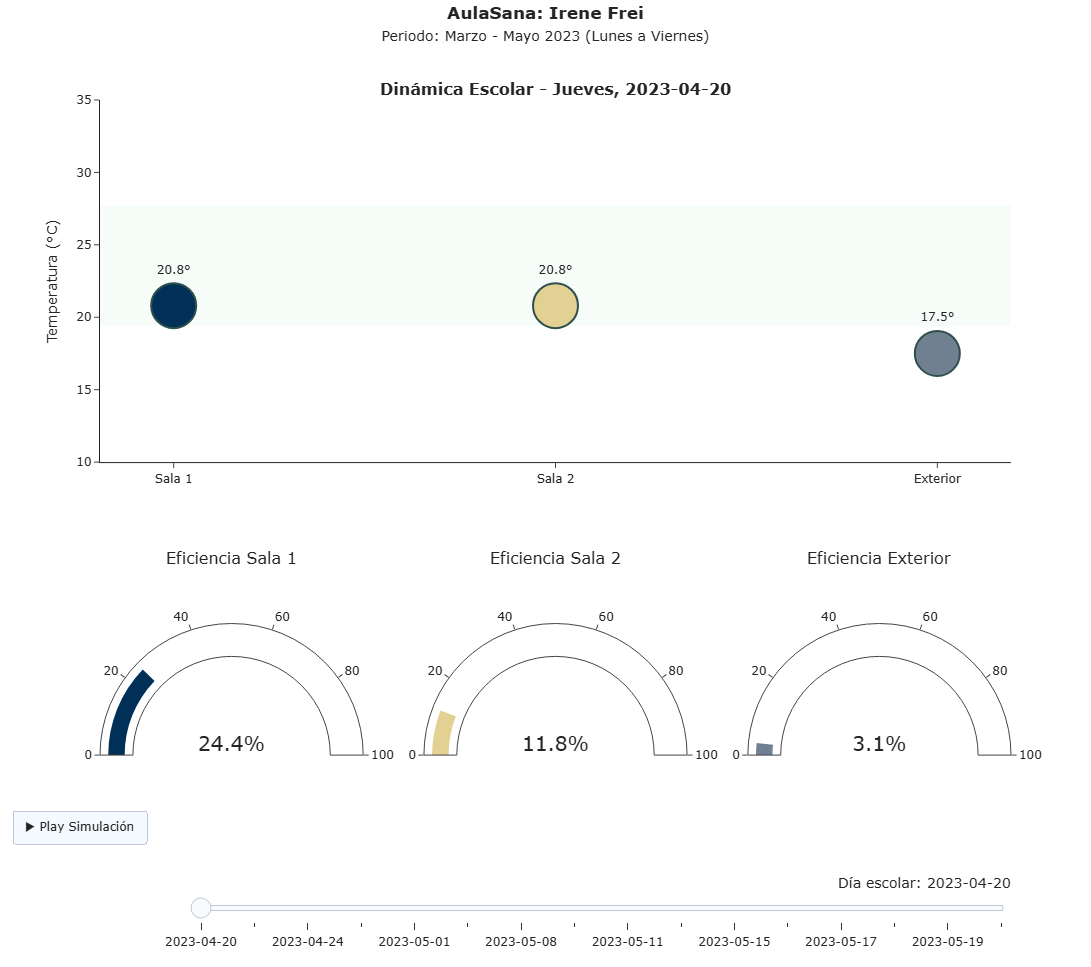

In [18]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. CONFIGURACIÓN INICIAL Y FILTRADO MULTI-NIVEL ---
nombre_colegio = 'Irene Frei' 

# Aplicamos los 4 filtros: Escuela + Año + Semana Escolar + Trimestre (Marzo-Mayo)
df_filtrado = df_final[
    (df_final['escuela'] == nombre_colegio) & 
    (df_final['date'].dt.year == 2023) &
    (df_final['date'].dt.dayofweek <= 4) &          # Lunes a Viernes
    (df_final['date'].dt.month.between(3, 5))       # <--- COMPLEMENTO: Marzo a Mayo
].copy()

def get_compliance(series):
    if len(series) == 0: return 0
    within_range = series.between(19.4, 27.7).sum()
    return round((within_range / len(series)) * 100, 1)

# --- 2. PROCESAMIENTO ---
if df_filtrado.empty:
    print(f"❌ Error: No hay datos para {nombre_colegio} en el periodo solicitado (Marzo-Mayo 2023)")
else:
    # Mapeo de días en español
    dias_espanol = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}
    
    df_filtrado['Day'] = df_filtrado['date'].dt.strftime('%Y-%m-%d')
    df_filtrado['DayName'] = df_filtrado['date'].dt.dayofweek.map(dias_espanol)
    
    days = sorted(df_filtrado['Day'].unique())
    
    cols_map = {'temp_int1': 'Sala 1', 'temp_int2': 'Sala 2', 'temp_ext': 'Exterior'}
    df_daily = df_filtrado.groupby(['Day', 'DayName'])[list(cols_map.keys())].mean().reset_index()
    df_daily = df_daily.rename(columns=cols_map).round(1)

    # --- 3. CREACIÓN DEL GRÁFICO ---
    fig = make_subplots(
        rows=2, cols=3,
        row_heights=[0.6, 0.4], 
        vertical_spacing=0.15,   
        specs=[[{"colspan": 3}, None, None],
               [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
        subplot_titles=(f"<b>Dinámica Escolar - {df_daily.iloc[0]['DayName']}, {days[0]}</b>", 
                        "Eficiencia Sala 1", "Eficiencia Sala 2", "Eficiencia Exterior")
    )

    categorias = ['Sala 1', 'Sala 2', 'Exterior']
    colors = ['#003057', '#E2D192', '#708090']

    # Trazas iniciales (Primer día de marzo)
    df_ini = df_daily.iloc[0]
    fig.add_trace(go.Scatter(
        x=categorias, y=[df_ini[c] for c in categorias],
        mode='markers+text', text=[f"{df_ini[c]}°" for c in categorias],
        textposition="top center", 
        marker=dict(size=45, color=colors, line=dict(width=2, color='DarkSlateGrey')),
        name="Temp Actual"
    ), row=1, col=1)

    for i, cat in enumerate(categorias):
        fig.add_trace(go.Indicator(
            mode="gauge+number", 
            value=get_compliance(df_filtrado[list(cols_map.keys())[i]]),
            number={'suffix': "%", 'font': {'size': 20}},
            gauge={'axis': {'range': [0, 100]}, 'bar': {'color': colors[i]}}
        ), row=2, col=i+1)

    # --- 4. ANIMACIÓN (Frames) ---
    frames = []
    for i, row in df_daily.iterrows():
        day_val = row['Day']
        name_val = row['DayName']
        
        frames.append(go.Frame(
            data=[
                go.Scatter(y=[row[c] for c in categorias], 
                           text=[f"{row[c]}°" for c in categorias]),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_int1'])),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_int2'])),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_ext']))
            ],
            name=day_val,
            layout=go.Layout(annotations=[
                dict(text=f"<b>Dinámica Escolar - {name_val}, {day_val}</b>", 
                     xref="paper", yref="paper", x=0.5, y=1.03, showarrow=False, font=dict(size=16))
            ])
        ))
    fig.frames = frames

    # --- 5. CONFIGURACIÓN DE SLIDER Y DISEÑO ---
    sliders = [{
        "active": 0,
        "yanchor": "top", "xanchor": "left",
        "currentvalue": {"font": {"size": 14}, "prefix": "Día escolar: ", "visible": True, "xanchor": "right"},
        "pad": {"b": 10, "t": 60},
        "len": 0.9, "x": 0.1, "y": 0,
        "steps": [{"args": [[f.name], {"frame": {"duration": 100, "redraw": True}, "mode": "immediate"}],
                   "label": f.name, "method": "animate"} for f in fig.frames]
    }]

    fig.update_layout(
        height=950, width=1100, template="simple_white", showlegend=False,
        sliders=sliders,
        updatemenus=[{
            "type": "buttons", "x": 0.05, "y": 0,
            "buttons": [{"label": "▶ Play Simulación", "method": "animate", 
                         "args": [None, {"frame": {"duration": 200, "redraw": True}, "fromcurrent": True}]}]
        }],
        title={
            'text': f"<b>AulaSana: {nombre_colegio}</b><br><span style='font-size:14px'>Periodo: Marzo - Mayo 2023 (Lunes a Viernes)</span>",
            'x': 0.5, 'y': 0.98, 'xanchor': 'center'
        }
    )

    # Área de confort ASHRAE 55
    fig.add_shape(
        type="rect", xref="paper", yref="y1",
        x0=0, x1=1, y0=19.4, y1=27.7,
        fillcolor="rgba(46, 204, 113, 0.15)", line_width=0, layer="below"
    )

    fig.update_yaxes(range=[10, 35], title="Temperatura (°C)", row=1, col=1)
    fig.show()

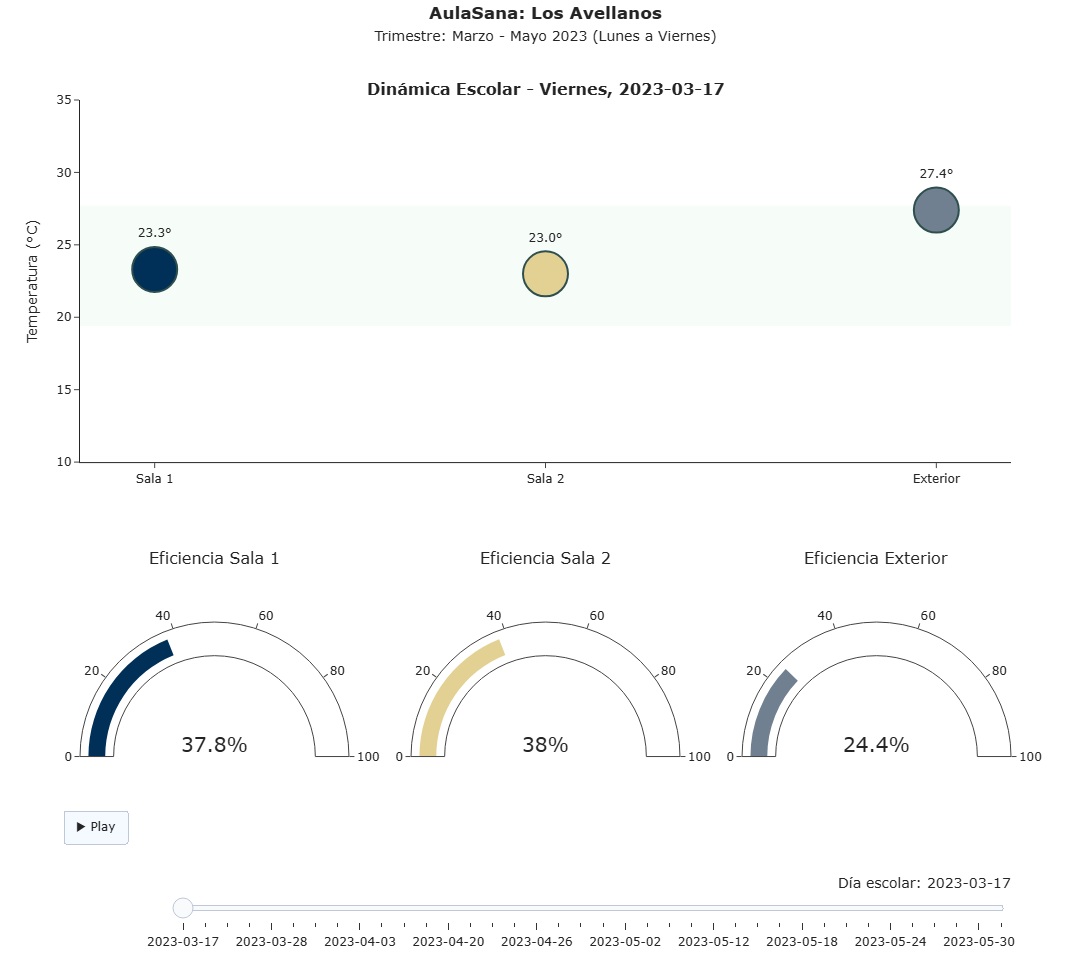

In [17]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. CONFIGURACIÓN INICIAL Y FILTRADO MULTI-NIVEL ---
nombre_colegio = 'Los Avellanos' 

# Aplicamos todos los filtros: Escuela + Año + Días Laborales + Rango de Meses
df_filtrado = df_final[
    (df_final['escuela'] == nombre_colegio) & 
    (df_final['date'].dt.year == 2023) &
    (df_final['date'].dt.dayofweek <= 4) &          # Lunes a Viernes
    (df_final['date'].dt.month.between(3, 5))       # <--- COMPLEMENTO: Marzo a Mayo
].copy()

def get_compliance(series):
    if len(series) == 0: return 0
    within_range = series.between(19.4, 27.7).sum()
    return round((within_range / len(series)) * 100, 1)

# --- 2. PROCESAMIENTO ---
if df_filtrado.empty:
    print(f"❌ Error: No hay datos para {nombre_colegio} en el periodo Marzo-Mayo 2023")
else:
    dias_espanol = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}
    
    df_filtrado['Day'] = df_filtrado['date'].dt.strftime('%Y-%m-%d')
    df_filtrado['DayName'] = df_filtrado['date'].dt.dayofweek.map(dias_espanol)
    
    days = sorted(df_filtrado['Day'].unique())
    
    cols_map = {'temp_int1': 'Sala 1', 'temp_int2': 'Sala 2', 'temp_ext': 'Exterior'}
    df_daily = df_filtrado.groupby(['Day', 'DayName'])[list(cols_map.keys())].mean().reset_index()
    df_daily = df_daily.rename(columns=cols_map).round(1)

    # --- 3. CREACIÓN DEL GRÁFICO ---
    fig = make_subplots(
        rows=2, cols=3,
        row_heights=[0.6, 0.4], 
        vertical_spacing=0.15,   
        specs=[[{"colspan": 3}, None, None],
               [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
        subplot_titles=(f"<b>Dinámica Escolar - {df_daily.iloc[0]['DayName']}, {days[0]}</b>", 
                        "Eficiencia Sala 1", "Eficiencia Sala 2", "Eficiencia Exterior")
    )

    categorias = ['Sala 1', 'Sala 2', 'Exterior']
    colors = ['#003057', '#E2D192', '#708090']

    # Trazas iniciales
    df_ini = df_daily.iloc[0]
    fig.add_trace(go.Scatter(
        x=categorias, y=[df_ini[c] for c in categorias],
        mode='markers+text', text=[f"{df_ini[c]}°" for c in categorias],
        textposition="top center", 
        marker=dict(size=45, color=colors, line=dict(width=2, color='DarkSlateGrey')),
        name="Temp Actual"
    ), row=1, col=1)

    for i, cat in enumerate(categorias):
        fig.add_trace(go.Indicator(
            mode="gauge+number", 
            value=get_compliance(df_filtrado[list(cols_map.keys())[i]]),
            number={'suffix': "%", 'font': {'size': 20}},
            gauge={'axis': {'range': [0, 100]}, 'bar': {'color': colors[i]}}
        ), row=2, col=i+1)

    # --- 4. ANIMACIÓN Y FECHAS (Frames) ---
    frames = []
    for i, row in df_daily.iterrows():
        day_val = row['Day']
        name_val = row['DayName']
        
        frames.append(go.Frame(
            data=[
                go.Scatter(y=[row[c] for c in categorias], 
                           text=[f"{row[c]}°" for c in categorias]),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_int1'])),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_int2'])),
                go.Indicator(value=get_compliance(df_filtrado[df_filtrado['Day'] <= day_val]['temp_ext']))
            ],
            name=day_val,
            layout=go.Layout(annotations=[
                dict(text=f"<b>Dinámica Escolar - {name_val}, {day_val}</b>", 
                     xref="paper", yref="paper", x=0.5, y=1.03, showarrow=False, font=dict(size=16))
            ])
        ))
    fig.frames = frames

    # --- 5. CONFIGURACIÓN DE SLIDER Y BOTONES ---
    sliders = [{
        "active": 0,
        "yanchor": "top", "xanchor": "left",
        "currentvalue": {"font": {"size": 14}, "prefix": "Día escolar: ", "visible": True, "xanchor": "right"},
        "pad": {"b": 10, "t": 60},
        "len": 0.9, "x": 0.1, "y": 0,
        "steps": [{"args": [[f.name], {"frame": {"duration": 100, "redraw": True}, "mode": "immediate"}],
                   "label": f.name, "method": "animate"} for f in fig.frames]
    }]

    fig.update_layout(
        height=950, width=1100, template="simple_white", showlegend=False,
        sliders=sliders,
        updatemenus=[{
            "type": "buttons", "x": 0.05, "y": 0,
            "buttons": [{"label": "▶ Play", "method": "animate", 
                         "args": [None, {"frame": {"duration": 200, "redraw": True}, "fromcurrent": True}]}]
        }],
        title={
            'text': f"<b>AulaSana: {nombre_colegio}</b><br><span style='font-size:14px'>Trimestre: Marzo - Mayo 2023 (Lunes a Viernes)</span>",
            'x': 0.5, 'y': 0.98, 'xanchor': 'center'
        }
    )

    # --- 6. ZONA DE CONFORT ---
    fig.add_shape(
        type="rect", xref="paper", yref="y1",
        x0=0, x1=1, y0=19.4, y1=27.7,
        fillcolor="rgba(46, 204, 113, 0.15)", line_width=0, layer="below"
    )

    fig.update_yaxes(range=[10, 35], title="Temperatura (°C)", row=1, col=1)
    fig.show()

In [19]:
pip install pywaffle

Note: you may need to restart the kernel to use updated packages.


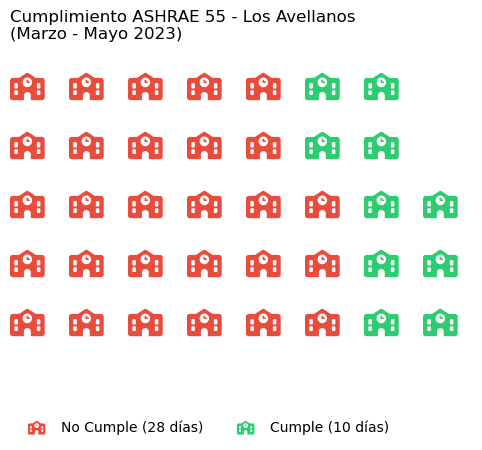

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle

# --- 1. PREPARACIÓN DE DATOS ---
# Filtramos por semana escolar y meses de marzo a mayo
df_periodo = df_final[
    (df_final['date'].dt.year == 2023) &
    (df_final['date'].dt.dayofweek <= 4) &
    (df_final['date'].dt.month.between(3, 5))
].copy()

# Definimos cumplimiento diario: un día cumple si el promedio de sus salas está en rango
df_periodo['Day'] = df_periodo['date'].dt.date
cumplimiento_diario = df_periodo.groupby(['escuela', 'Day'])[['temp_int1', 'temp_int2']].mean().mean(axis=1)
cumplimiento_diario = cumplimiento_diario.between(19.4, 27.7).reset_index(name='Cumple')

# --- 2. RESUMEN POR COLEGIO ---
# Contamos cuántos días cumplieron y cuántos no por colegio
resumen = cumplimiento_diario.groupby(['escuela', 'Cumple']).size().unstack(fill_value=0)
resumen.columns = ['No Cumple', 'Cumple']

# --- 3. GENERAR EL GRÁFICO DE WAFFLE ---
# Elegimos un colegio para el ejemplo (o puedes iterar sobre ellos)
colegio_target = 'Los Avellanos'
datos_waffle = resumen.loc[colegio_target].to_dict()

fig = plt.figure(
    FigureClass=Waffle,
    rows=5, 
    values=datos_waffle,
    colors=["#e74c3c", "#2ecc71"], # Rojo para falla, Verde para éxito
    title={'label': f'Cumplimiento ASHRAE 55 - {colegio_target}\n(Marzo - Mayo 2023)', 'loc': 'left'},
    labels=[f"{k} ({v} días)" for k, v in datos_waffle.items()],
    legend={'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(datos_waffle), 'framealpha': 0},
    icons='school', # Icono de escuela
    font_size=20,
    icon_legend=True,
    figsize=(10, 5)
)

plt.show()